### use phasenet and EQT api in seisbench to test on raw data

In [1]:
import seisbench.models as sbm
import obspy

d:\Anaconda\envs\seisbench\lib\site-packages\seisbench\__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
model = sbm.PhaseNet()
print(model)

Component order:	ZNE
SeisBench model		PhaseNet

PhaseNet(
  (inc): Conv1d(3, 8, kernel_size=(7,), stride=(1,), padding=same)
  (in_bn): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (down_branch): ModuleList(
    (0): ModuleList(
      (0): Conv1d(8, 8, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(8, 8, kernel_size=(7,), stride=(4,), padding=(3,), bias=False)
      (3): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ModuleList(
      (0): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(4,), bias=False)
      (3): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ModuleList(
      

In [3]:
pretrained_weights = sbm.PhaseNet.list_pretrained(details=True)
for key, value in pretrained_weights.items():
    print(f"{key}:\n{value}\n-----------------------\n")

diting:
Model trained on the DiTing dataset, a large-scale Chinese seismic benchmark dataset.
For models fine-tuned on individual regions in China, please see: https://github.com/JUNZHU-SEIS/USTC-Pickers
If you use this model, please reference: Zhu J, Li ZF and Fang LH (2023). USTC-Pickers: a Unified Set of seismic phase pickers Transfer learned for China. Earthq Sci 36(2): 95–112, doi: 10.1016/j.eqs.2023.03.001
-----------------------

ethz:
Model trained on ETHZ for 100 epochs with a learning rate of 0.01.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be adjusted.
When using this model, please reference the SeisBench publications listed at https://github.com/seisbench/seisbench

Jannes Münchmeyer, Jack Woollam (munchmej@gfz-potsdam.de, jack.woollam@kit.edu)
-----------------------

geofon:
Model trained on GEOFON for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-d

In [6]:
model = sbm.PhaseNet.from_pretrained("original")
print(model.weights_docstring)

Original PhaseNet model from Zhu et al. (2018). Originally published under MIT License. Original available at https://github.com/AI4EPS/PhaseNet/tree/master/model/190703-214543 . 

Converted to SeisBench by Jannes Münchmeyer (munchmej@univ-grenoble-alpes.fr) with help from Sacha Lapins, Yiyuan Zhong, and Jun Zhu


In [5]:
import obspy
mseed_file = "D:\mseed_merged\QJ.QJ01._centaur-3_8480_20230101_000000.miniseed_segment_0.mseed"
stream = obspy.read(mseed_file)

In [7]:
annotations = model.annotate(stream)
print(annotations)

3 Trace(s) in Stream:
QJ.QJ01..PhaseNet_N | 2023-01-01T00:00:02.500000Z - 2023-01-01T00:03:17.490000Z | 100.0 Hz, 19500 samples
QJ.QJ01..PhaseNet_P | 2023-01-01T00:00:02.500000Z - 2023-01-01T00:03:17.490000Z | 100.0 Hz, 19500 samples
QJ.QJ01..PhaseNet_S | 2023-01-01T00:00:02.500000Z - 2023-01-01T00:03:17.490000Z | 100.0 Hz, 19500 samples


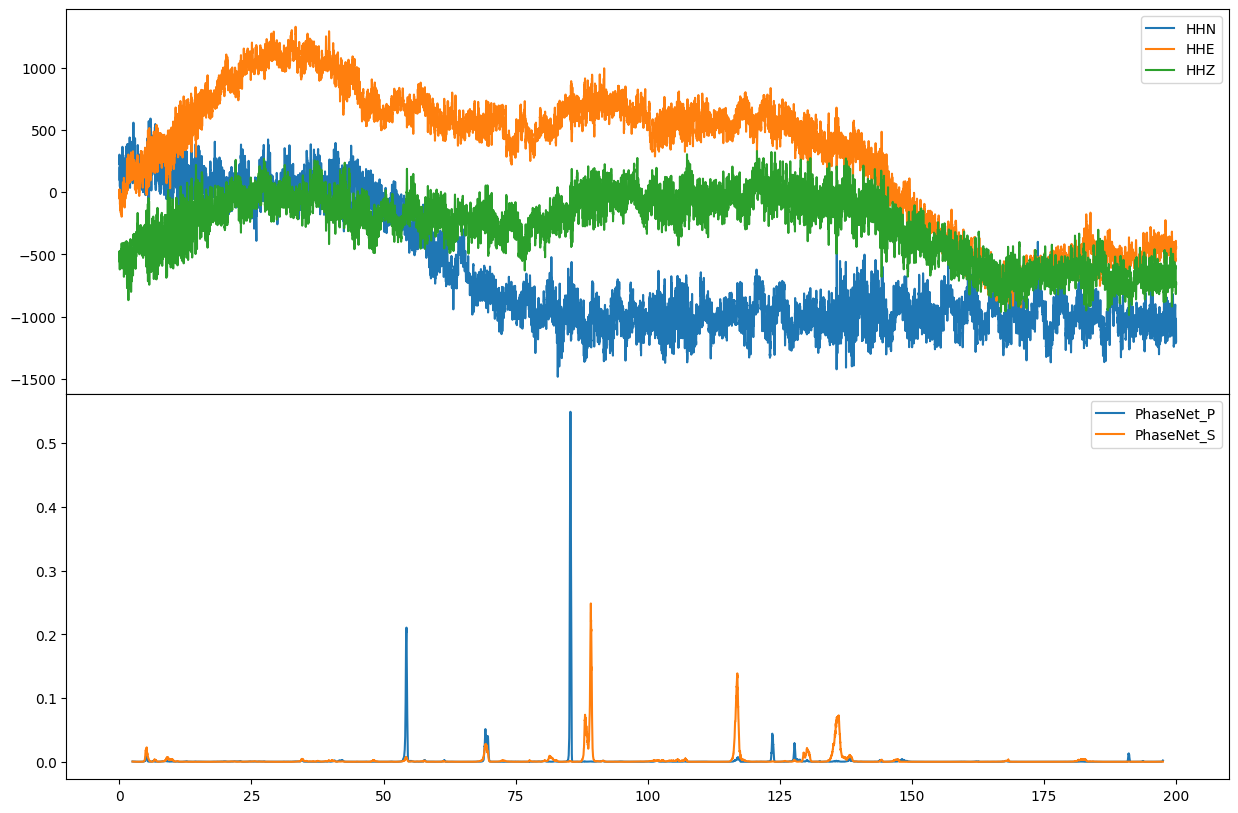

In [9]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15, 10))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={"hspace": 0})

offset = annotations[0].stats.starttime - stream[0].stats.starttime
for i in range(3):
    axs[0].plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
    if annotations[i].stats.channel[-1] != "N":  # Do not plot noise curve
        axs[1].plot(
            annotations[i].times() + offset,
            annotations[i].data,
            label=annotations[i].stats.channel,
        )

axs[0].legend()
axs[1].legend()

In [6]:
model.to_preferred_device(verbose=True)

Model device: cpu


In [7]:
import os

file_path = "d:/mseed_merged/2022_8_11"
batch_size = 100
mseed_files = [f for f in os.listdir(file_path) if f.endswith(".mseed")]
total_files = len(mseed_files)
print(f"📁 共找到 {total_files} 个 mseed 文件")
# annotations = model.annotate(stream)
# print(annotations)

📁 共找到 665189 个 mseed 文件


In [8]:
# 输出文件
picks_csv = "phasenet_picks_2208_11raw.csv"
# detections_csv = "phasenet_detections_2212raw.csv"

In [9]:
# 批处理
for i in range(0, total_files, batch_size):
    batch_files = mseed_files[i:i + batch_size]
    print(f"\n▶ 正在处理第 {i // batch_size + 1} 批，共 {len(batch_files)} 个文件")

    # 在读取时直接合并
    batch_stream = obspy.Stream()
    for fname in batch_files:
        fpath = os.path.join(file_path, fname)
        try:
            batch_stream.extend(obspy.read(fpath))
        except Exception as e:
            print(f"❌ 无法读取 {fname}: {e}")

    if len(batch_stream) == 0:
        continue

    # 调用模型
    try:
        output = model.classify(batch_stream)
    except Exception as e:
        print(f"❌ 模型运行失败: {e}")
        continue

    # 保存结果
    df_picks = output.picks.to_dataframe()
    # print(output.picks)
    # print(output.__dict__)
    # df_detections = output.detections.to_dataframe()

    # 追加写入 CSV
    write_header = i == 0
    df_picks.to_csv(picks_csv, mode="a", header=write_header, index=False)
    # df_detections.to_csv(detections_csv, mode="a", header=write_header, index=False)

    print(f"✅ 第 {i // batch_size + 1} 批完成，结果已追加保存")

print("\n🎉 全部文件处理完成！")
print(f"结果文件：\n - {picks_csv}\n ")


▶ 正在处理第 1 批，共 100 个文件
✅ 第 1 批完成，结果已追加保存

▶ 正在处理第 2 批，共 100 个文件
✅ 第 2 批完成，结果已追加保存

▶ 正在处理第 3 批，共 100 个文件
✅ 第 3 批完成，结果已追加保存

▶ 正在处理第 4 批，共 100 个文件
✅ 第 4 批完成，结果已追加保存

▶ 正在处理第 5 批，共 100 个文件
✅ 第 5 批完成，结果已追加保存

▶ 正在处理第 6 批，共 100 个文件
✅ 第 6 批完成，结果已追加保存

▶ 正在处理第 7 批，共 100 个文件
✅ 第 7 批完成，结果已追加保存

▶ 正在处理第 8 批，共 100 个文件
✅ 第 8 批完成，结果已追加保存

▶ 正在处理第 9 批，共 100 个文件
✅ 第 9 批完成，结果已追加保存

▶ 正在处理第 10 批，共 100 个文件
✅ 第 10 批完成，结果已追加保存

▶ 正在处理第 11 批，共 100 个文件
✅ 第 11 批完成，结果已追加保存

▶ 正在处理第 12 批，共 100 个文件
✅ 第 12 批完成，结果已追加保存

▶ 正在处理第 13 批，共 100 个文件
✅ 第 13 批完成，结果已追加保存

▶ 正在处理第 14 批，共 100 个文件
✅ 第 14 批完成，结果已追加保存

▶ 正在处理第 15 批，共 100 个文件
✅ 第 15 批完成，结果已追加保存

▶ 正在处理第 16 批，共 100 个文件
✅ 第 16 批完成，结果已追加保存

▶ 正在处理第 17 批，共 100 个文件
✅ 第 17 批完成，结果已追加保存

▶ 正在处理第 18 批，共 100 个文件
✅ 第 18 批完成，结果已追加保存

▶ 正在处理第 19 批，共 100 个文件
✅ 第 19 批完成，结果已追加保存

▶ 正在处理第 20 批，共 100 个文件
✅ 第 20 批完成，结果已追加保存

▶ 正在处理第 21 批，共 100 个文件
✅ 第 21 批完成，结果已追加保存

▶ 正在处理第 22 批，共 100 个文件
✅ 第 22 批完成，结果已追加保存

▶ 正在处理第 23 批，共 100 个文件
✅ 第 23 批完成，结果已追加保存

▶ 正在处理第 24 批，共 100 个文件
✅ 第 2

### after filter

In [2]:
model = sbm.EQTransformer.from_pretrained("stead")
print(model.weights_docstring)

Model trained on STEAD for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be adjusted.
When using this model, please reference the SeisBench publications listed at https://github.com/seisbench/seisbench

Jannes Münchmeyer, Jack Woollam (munchmej@gfz-potsdam.de, jack.woollam@kit.edu)


In [4]:
# 输出文件
picks_csv = "eqt_picks_raw2023.csv"
detections_csv = "eqt_detections_raw2023.csv"

In [5]:
# === 批处理 ===
for i in range(0, total_files, batch_size):
    batch_files = mseed_files[i:i + batch_size]
    print(f"\n▶ 正在处理第 {i // batch_size + 1} 批，共 {len(batch_files)} 个文件")

    batch_stream = obspy.Stream()

    # === 在读取时直接 extend ===
    for fname in batch_files:
        fpath = os.path.join(file_path, fname)
        try:
            batch_stream.extend(obspy.read(fpath))
        except Exception as e:
            print(f"❌ 无法读取 {fname}: {e}")

    if len(batch_stream) == 0:
        continue

    # === 🧠 对整个 batch 进行滤波 ===
    try:
        batch_stream.filter("bandstop", freqmin=1.0, freqmax=7.0, corners=4, zerophase=True)
    except Exception as e:
        print(f"⚠️ 滤波失败: {e}")
        continue

    # === 🔍 调用模型 ===
    try:
        output = model.classify(batch_stream)
    except Exception as e:
        print(f"❌ 模型运行失败: {e}")
        continue

    # === 📄 转成 DataFrame 并写入 CSV ===
    df_picks = output.picks.to_dataframe()
    df_detections = output.detections.to_dataframe()

    write_header = i == 0
    df_picks.to_csv(picks_csv, mode="a", header=write_header, index=False)
    df_detections.to_csv(detections_csv, mode="a", header=write_header, index=False)

    print(f"✅ 第 {i // batch_size + 1} 批完成，结果已保存")

print("\n🎉 全部文件处理完成！")
print(f"输出文件：\n - {picks_csv}\n - {detections_csv}")


▶ 正在处理第 1 批，共 100 个文件
✅ 第 1 批完成，结果已保存

▶ 正在处理第 2 批，共 100 个文件
✅ 第 2 批完成，结果已保存

▶ 正在处理第 3 批，共 100 个文件
✅ 第 3 批完成，结果已保存

▶ 正在处理第 4 批，共 100 个文件
✅ 第 4 批完成，结果已保存

▶ 正在处理第 5 批，共 100 个文件
✅ 第 5 批完成，结果已保存

▶ 正在处理第 6 批，共 100 个文件
✅ 第 6 批完成，结果已保存

▶ 正在处理第 7 批，共 100 个文件
✅ 第 7 批完成，结果已保存

▶ 正在处理第 8 批，共 100 个文件
✅ 第 8 批完成，结果已保存

▶ 正在处理第 9 批，共 100 个文件
✅ 第 9 批完成，结果已保存

▶ 正在处理第 10 批，共 100 个文件
✅ 第 10 批完成，结果已保存

▶ 正在处理第 11 批，共 100 个文件
✅ 第 11 批完成，结果已保存

▶ 正在处理第 12 批，共 100 个文件
✅ 第 12 批完成，结果已保存

▶ 正在处理第 13 批，共 100 个文件
✅ 第 13 批完成，结果已保存

▶ 正在处理第 14 批，共 100 个文件
✅ 第 14 批完成，结果已保存

▶ 正在处理第 15 批，共 100 个文件
✅ 第 15 批完成，结果已保存

▶ 正在处理第 16 批，共 100 个文件
✅ 第 16 批完成，结果已保存

▶ 正在处理第 17 批，共 100 个文件
✅ 第 17 批完成，结果已保存

▶ 正在处理第 18 批，共 100 个文件
✅ 第 18 批完成，结果已保存

▶ 正在处理第 19 批，共 100 个文件
✅ 第 19 批完成，结果已保存

▶ 正在处理第 20 批，共 100 个文件
✅ 第 20 批完成，结果已保存

▶ 正在处理第 21 批，共 100 个文件
✅ 第 21 批完成，结果已保存

▶ 正在处理第 22 批，共 100 个文件
✅ 第 22 批完成，结果已保存

▶ 正在处理第 23 批，共 100 个文件
✅ 第 23 批完成，结果已保存

▶ 正在处理第 24 批，共 100 个文件
✅ 第 24 批完成，结果已保存

▶ 正在处理第 25 批，共 100 个文件
✅ 第 25 批完成

## now read the denoised h5 file and use Phasenet & Eqt model

In [27]:
import os
import h5py
import pandas as pd
from obspy import Stream, Trace
h5_file = r"d:/hdf5_merged/QJ_202212_denoised_merged.hdf5"
batch_size = 100


In [28]:
# 收集所有 Dataset 路径
# ===========================
with h5py.File(h5_file, "r") as f:
    dataset_paths = [
        (group_name, sub_name)
        for group_name in f.keys() if group_name.startswith("earthquake")
        for sub_name in f[group_name].keys()
    ]
total_files = len(dataset_paths)
print(f"✅ 共检测到 {total_files} 个 Dataset 可处理")

✅ 共检测到 66686 个 Dataset 可处理


In [29]:
picks_csv = "phasenet_denoised2212_picks.csv"
model = sbm.PhaseNet.from_pretrained("original")

In [30]:
from obspy import Stream, Trace, UTCDateTime
# ===========================
# 批处理
# ===========================
all_picks, all_detections = [], []
sampling_rate = 100.0  # 根据实际数据设置
total = len(dataset_paths)

for i in range(0, total, batch_size):
    batch = dataset_paths[i:i + batch_size]
    print(f"\n▶ 处理第 {i // batch_size + 1} 批，共 {len(batch)} 个 dataset")

    for group_name, sub_name in batch:
        try:
            with h5py.File(h5_file, "r") as f:
                data = f[group_name][sub_name][:]  # (samples, 3)
        except Exception as e:
            print(f"❌ 无法读取 {group_name}/{sub_name}: {e}")
            continue

        # 转换为 (3, samples)
        data = data.T

        # 构建三分量 Stream，确保完全一致
        stream = Stream()
        channels = ["EHZ", "EHN", "EHE"]
        starttime = UTCDateTime(0)
        npts = data.shape[1]

        for j in range(3):
            tr = Trace(data=data[j])
            tr.stats.station = sub_name
            tr.stats.channel = channels[j]
            tr.stats.network = "QJ"
            tr.stats.sampling_rate = sampling_rate
            tr.stats.starttime = starttime
            tr.stats.npts = npts
            stream.append(tr)

        # 确保三分量对齐
        stream.merge(method=1, fill_value=0)

        try:
            output = model.classify(stream)

            if len(output.picks) > 0:
                all_picks.append(output.picks.to_dataframe())

            # if output.detections is not None and len(output.detections) > 0:
            #     all_detections.append(output.detections.to_dataframe())

        except Exception as e:
            print(f"❌ 模型运行失败 {sub_name}: {e}")
            continue

    # 每批写入
    if all_picks:
        pd.concat(all_picks).to_csv(picks_csv, mode="a", header=(i == 0), index=False)
        all_picks = []
    if all_detections:
        # pd.concat(all_detections).to_csv(detections_csv, mode="a", header=(i == 0), index=False)
        all_detections = []

    print(f"✅ 第 {i // batch_size + 1} 批完成")

print("\n🎉 全部 dataset 处理完成！")
print(f"结果文件：\n - {picks_csv}\n ")


▶ 处理第 1 批，共 100 个 dataset
✅ 第 1 批完成

▶ 处理第 2 批，共 100 个 dataset
✅ 第 2 批完成

▶ 处理第 3 批，共 100 个 dataset
✅ 第 3 批完成

▶ 处理第 4 批，共 100 个 dataset
✅ 第 4 批完成

▶ 处理第 5 批，共 100 个 dataset
✅ 第 5 批完成

▶ 处理第 6 批，共 100 个 dataset
✅ 第 6 批完成

▶ 处理第 7 批，共 100 个 dataset
✅ 第 7 批完成

▶ 处理第 8 批，共 100 个 dataset
✅ 第 8 批完成

▶ 处理第 9 批，共 100 个 dataset
✅ 第 9 批完成

▶ 处理第 10 批，共 100 个 dataset
✅ 第 10 批完成

▶ 处理第 11 批，共 100 个 dataset
✅ 第 11 批完成

▶ 处理第 12 批，共 100 个 dataset
✅ 第 12 批完成

▶ 处理第 13 批，共 100 个 dataset
✅ 第 13 批完成

▶ 处理第 14 批，共 100 个 dataset
✅ 第 14 批完成

▶ 处理第 15 批，共 100 个 dataset
✅ 第 15 批完成

▶ 处理第 16 批，共 100 个 dataset
✅ 第 16 批完成

▶ 处理第 17 批，共 100 个 dataset
✅ 第 17 批完成

▶ 处理第 18 批，共 100 个 dataset
✅ 第 18 批完成

▶ 处理第 19 批，共 100 个 dataset
✅ 第 19 批完成

▶ 处理第 20 批，共 100 个 dataset
✅ 第 20 批完成

▶ 处理第 21 批，共 100 个 dataset
✅ 第 21 批完成

▶ 处理第 22 批，共 100 个 dataset
✅ 第 22 批完成

▶ 处理第 23 批，共 100 个 dataset
✅ 第 23 批完成

▶ 处理第 24 批，共 100 个 dataset
✅ 第 24 批完成

▶ 处理第 25 批，共 100 个 dataset
✅ 第 25 批完成

▶ 处理第 26 批，共 100 个 dataset
✅ 第 26 批完成

▶ 处

### eqt on denoised

In [31]:
picks_csv = "eqt_denoised2212_picks.csv"
detections_csv = "eqt_denoised2212_detections.csv"
model = sbm.EQTransformer.from_pretrained("stead")

In [32]:

from obspy import Stream, Trace, UTCDateTime
# ===========================
# 批处理
# ===========================
all_picks, all_detections = [], []
sampling_rate = 100.0  # 根据实际数据设置
total = len(dataset_paths)

for i in range(0, total, batch_size):
    batch = dataset_paths[i:i + batch_size]
    print(f"\n▶ 处理第 {i // batch_size + 1} 批，共 {len(batch)} 个 dataset")

    for group_name, sub_name in batch:
        try:
            with h5py.File(h5_file, "r") as f:
                data = f[group_name][sub_name][:]  # (samples, 3)
        except Exception as e:
            print(f"❌ 无法读取 {group_name}/{sub_name}: {e}")
            continue

        # 转换为 (3, samples)
        data = data.T

        # 构建三分量 Stream，确保完全一致
        stream = Stream()
        channels = ["EHZ", "EHN", "EHE"]
        starttime = UTCDateTime(0)
        npts = data.shape[1]

        for j in range(3):
            tr = Trace(data=data[j])
            tr.stats.station = sub_name
            tr.stats.channel = channels[j]
            tr.stats.network = "QJ"
            tr.stats.sampling_rate = sampling_rate
            tr.stats.starttime = starttime
            tr.stats.npts = npts
            stream.append(tr)

        # 确保三分量对齐
        stream.merge(method=1, fill_value=0)
        # ✅ 滤波：在调用模型前进行
        stream.filter("bandstop", freqmin=1.0, freqmax=7.0, corners=4, zerophase=True)

        try:
            output = model.classify(stream)

            if len(output.picks) > 0:
                all_picks.append(output.picks.to_dataframe())

            if output.detections is not None and len(output.detections) > 0:
                all_detections.append(output.detections.to_dataframe())

        except Exception as e:
            print(f"❌ 模型运行失败 {sub_name}: {e}")
            continue

    # 每批写入
    if all_picks:
        pd.concat(all_picks).to_csv(picks_csv, mode="a", header=(i == 0), index=False)
        all_picks = []
    if all_detections:
        pd.concat(all_detections).to_csv(detections_csv, mode="a", header=(i == 0), index=False)
        all_detections = []

    print(f"✅ 第 {i // batch_size + 1} 批完成")


print("\n🎉 全部处理完成！")
print(f"结果文件：\n - {picks_csv}\n - {detections_csv}")


▶ 处理第 1 批，共 100 个 dataset
✅ 第 1 批完成

▶ 处理第 2 批，共 100 个 dataset
✅ 第 2 批完成

▶ 处理第 3 批，共 100 个 dataset
✅ 第 3 批完成

▶ 处理第 4 批，共 100 个 dataset
✅ 第 4 批完成

▶ 处理第 5 批，共 100 个 dataset
✅ 第 5 批完成

▶ 处理第 6 批，共 100 个 dataset
✅ 第 6 批完成

▶ 处理第 7 批，共 100 个 dataset
✅ 第 7 批完成

▶ 处理第 8 批，共 100 个 dataset
✅ 第 8 批完成

▶ 处理第 9 批，共 100 个 dataset
✅ 第 9 批完成

▶ 处理第 10 批，共 100 个 dataset
✅ 第 10 批完成

▶ 处理第 11 批，共 100 个 dataset
✅ 第 11 批完成

▶ 处理第 12 批，共 100 个 dataset
✅ 第 12 批完成

▶ 处理第 13 批，共 100 个 dataset
✅ 第 13 批完成

▶ 处理第 14 批，共 100 个 dataset
✅ 第 14 批完成

▶ 处理第 15 批，共 100 个 dataset
✅ 第 15 批完成

▶ 处理第 16 批，共 100 个 dataset
✅ 第 16 批完成

▶ 处理第 17 批，共 100 个 dataset
✅ 第 17 批完成

▶ 处理第 18 批，共 100 个 dataset
✅ 第 18 批完成

▶ 处理第 19 批，共 100 个 dataset
✅ 第 19 批完成

▶ 处理第 20 批，共 100 个 dataset
✅ 第 20 批完成

▶ 处理第 21 批，共 100 个 dataset
✅ 第 21 批完成

▶ 处理第 22 批，共 100 个 dataset
✅ 第 22 批完成

▶ 处理第 23 批，共 100 个 dataset
✅ 第 23 批完成

▶ 处理第 24 批，共 100 个 dataset
✅ 第 24 批完成

▶ 处理第 25 批，共 100 个 dataset
✅ 第 25 批完成

▶ 处理第 26 批，共 100 个 dataset
✅ 第 26 批完成

▶ 处